## 1. ライブラリのインポートとセットアップ

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import cclib

    print(f"cclib version: {cclib.__version__}")
except ImportError:
    print("cclibがインストールされていません。インストールします...")
    import subprocess

    subprocess.check_call(["pip", "install", "cclib"])
    import cclib

    print(f"cclib version: {cclib.__version__}")

# 作業ディレクトリの設定
base_dir = Path("/home/yamamoto/Work/chemistry/orca-work/MEA_water")
print(f"Base directory: {base_dir}")

cclib version: 1.8.1
Base directory: /home/yamamoto/Work/chemistry/orca-work/MEA_water


## 2. 計算結果の読み込み

In [2]:
# 各計算のログファイルパス
files = {
    "reactant": base_dir / "react_opt" / "reactopt.log",
    "ts": base_dir / "tsopt" / "tsopt_freq.log",
    "product": base_dir / "prod_opt" / "prodopt.log",
}

# ファイルの存在確認
for name, path in files.items():
    if path.exists():
        print(f"✓ {name}: {path.name} (size: {path.stat().st_size / 1024:.1f} KB)")
    else:
        print(f"✗ {name}: {path.name} not found")

✓ reactant: reactopt.log (size: 427.0 KB)
✓ ts: tsopt_freq.log (size: 1493.6 KB)
✓ product: prodopt.log (size: 1990.5 KB)


In [ ]:
# cclibでのパースはORCA 6.1で問題があるため、直接ログから抽出
import re

data = {}


def extract_orca_data(log_file):
    """ORCAログファイルからエネルギーと振動数を抽出"""
    result = {}

    with open(log_file, "r") as f:
        content = f.read()

    # 最終エネルギー（最後の出現を取得）
    energies = re.findall(r"FINAL SINGLE POINT ENERGY\s+([-\d.]+)", content)
    if energies:
        result["energy"] = float(energies[-1])

    # 振動数
    freq_section = re.search(
        r"VIBRATIONAL FREQUENCIES\s*\n-+\s*\n\s*Scaling factor.*?\n\s*\n(.*?)\n\n",
        content,
        re.DOTALL,
    )
    if freq_section:
        freq_lines = freq_section.group(1).strip().split("\n")
        freqs = []
        for line in freq_lines:
            match = re.search(r"^\s*\d+:\s+([-\d.]+)\s+cm", line)
            if match:
                freqs.append(float(match.group(1)))
        result["frequencies"] = np.array(freqs)

    # 原子数
    natom_match = re.search(r"Number of atoms\s+\.\.\.\s+(\d+)", content)
    if natom_match:
        result["natom"] = int(natom_match.group(1))

    return result


for name, path in files.items():
    if path.exists():
        print(f"\nParsing {name}...")
        try:
            parsed = extract_orca_data(path)
            if "energy" in parsed:
                data[name] = parsed
                print(f"  Successfully parsed: {name}")
                print(f"  Atoms: {parsed.get('natom', 'N/A')}")
                print(f"  Energy: {parsed['energy']:.8f} Eh")
                if "frequencies" in parsed:
                    print(f"  Frequencies: {len(parsed['frequencies'])} modes")
            else:
                print(f"  Failed to extract energy from: {name}")
        except Exception as e:
            print(f"  Error parsing {name}: {e}")


Parsing reactant...
  Successfully parsed: reactant
  Atoms: 14
  Energy: -399.09162695 Eh
  Frequencies: 42 modes

Parsing ts...
  Successfully parsed: ts
  Atoms: 14
  Energy: -399.08744203 Eh
  Frequencies: 42 modes

Parsing product...
  Successfully parsed: product
  Atoms: 14
  Energy: -399.09273087 Eh
  Frequencies: 42 modes


## 3. エネルギーの抽出と比較

In [ ]:
# 最終エネルギーの取得
energies = {}
for name, parsed_data in data.items():
    if "energy" in parsed_data:
        energy_Eh = parsed_data["energy"]
        energies[name] = energy_Eh
        print(f"{name:12s}: {energy_Eh:.8f} Eh")

# 相対エネルギーの計算（kcal/mol）
print("\n=== 相対エネルギー (kcal/mol) ===")
if "reactant" in energies:
    ref_energy = energies["reactant"]
    print(f"基準: Reactant = 0.00 kcal/mol")
    for name, energy in energies.items():
        rel_energy = (energy - ref_energy) * 627.509474  # Hartree to kcal/mol
        print(f"{name:12s}: {rel_energy:+8.2f} kcal/mol")

reactant    : -399.09162695 Eh
ts          : -399.08744203 Eh
product     : -399.09273087 Eh

=== 相対エネルギー (kcal/mol) ===
基準: Reactant = 0.00 kcal/mol
reactant    :    +0.00 kcal/mol
ts          :    +2.63 kcal/mol
product     :    -0.69 kcal/mol


## 4. 振動解析（虚振動の確認）

In [ ]:
# 振動数の解析
print("=== 振動解析 ===")
for name, parsed_data in data.items():
    if "frequencies" in parsed_data:
        freqs = parsed_data["frequencies"]
        print(f"\n{name}:")
        print(f"  総振動数: {len(freqs)}")

        # 虚振動のチェック
        imaginary = freqs[freqs < 0]
        if len(imaginary) > 0:
            print(f"  ⚠️  虚振動: {len(imaginary)} 個")
            for i, freq in enumerate(imaginary):
                print(f"    {i+1}. {freq:.2f} cm⁻¹")
        else:
            print(f"  ✓ 虚振動なし（真の極小構造）")

        # 最小の実振動
        real_freqs = freqs[freqs > 0]
        if len(real_freqs) > 0:
            print(f"  最小振動数: {real_freqs[0]:.2f} cm⁻¹")
            print(f"  最大振動数: {real_freqs[-1]:.2f} cm⁻¹")
    else:
        print(f"\n{name}: 振動解析データなし")

=== 振動解析 ===

reactant:
  総振動数: 42
  ✓ 虚振動なし（真の極小構造）
  最小振動数: 41.47 cm⁻¹
  最大振動数: 3861.60 cm⁻¹

ts:
  総振動数: 42
  ⚠️  虚振動: 1 個
    1. -223.41 cm⁻¹
  最小振動数: 32.09 cm⁻¹
  最大振動数: 3865.07 cm⁻¹

product:
  総振動数: 42
  ⚠️  虚振動: 1 個
    1. -9.87 cm⁻¹
  最小振動数: 5.46 cm⁻¹
  最大振動数: 3868.79 cm⁻¹


## 5. エネルギーダイアグラムの作成


エネルギーダイアグラムを保存: /home/yamamoto/Work/chemistry/orca-work/MEA_water/analysis/energy_diagram.png


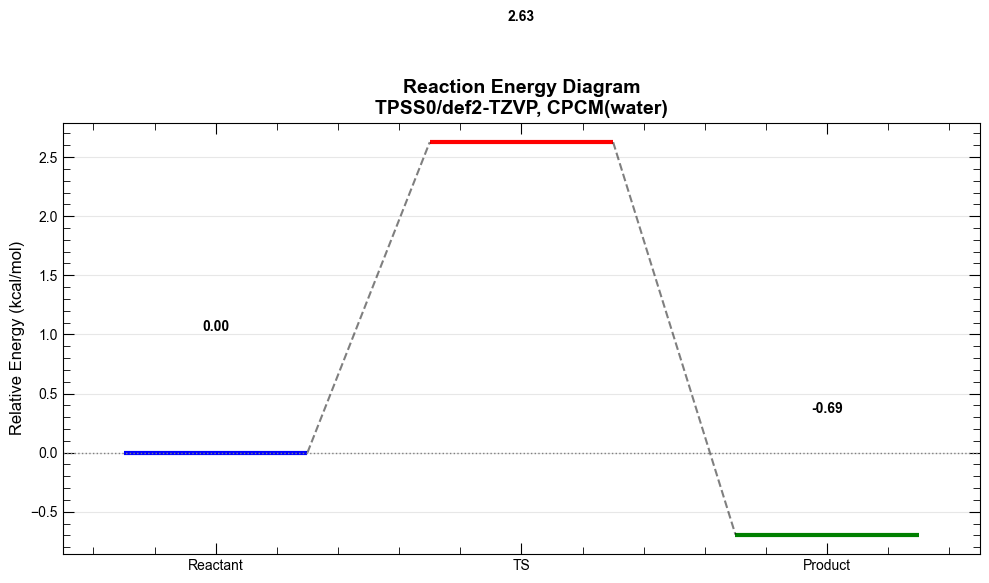

In [12]:
# エネルギーダイアグラムのプロット
if len(energies) >= 2:
    fig, ax = plt.subplots(figsize=(10, 6))

    # 相対エネルギーの計算
    ref_energy = energies.get("reactant", list(energies.values())[0])

    # プロット用データの準備
    positions = {"reactant": 0, "ts": 1, "product": 2}
    labels = {"reactant": "Reactant", "ts": "TS", "product": "Product"}
    colors = {"reactant": "blue", "ts": "red", "product": "green"}

    plot_data = []
    for name in ["reactant", "ts", "product"]:
        if name in energies:
            x = positions[name]
            y = (energies[name] - ref_energy) * 627.509474  # kcal/mol
            plot_data.append((x, y, labels[name], colors[name]))

    # エネルギー準位の描画
    for i, (x, y, label, color) in enumerate(plot_data):
        ax.hlines(y, x - 0.3, x + 0.3, colors=color, linewidth=3, label=label)
        ax.text(
            x,
            y + 1,
            f"{y:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    # 接続線の描画
    for i in range(len(plot_data) - 1):
        x1, y1, _, _ = plot_data[i]
        x2, y2, _, _ = plot_data[i + 1]
        ax.plot([x1 + 0.3, x2 - 0.3], [y1, y2], "k--", alpha=0.5)

    ax.set_xlim(-0.5, 2.5)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Reactant", "TS", "Product"])
    ax.set_ylabel("Relative Energy (kcal/mol)", fontsize=12)
    ax.set_title(
        "Reaction Energy Diagram\nTPSS0/def2-TZVP, CPCM(water)",
        fontsize=14,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3, axis="y")
    ax.axhline(y=0, color="gray", linestyle=":", linewidth=1)

    plt.tight_layout()

    # 保存
    output_path = base_dir / "analysis" / "energy_diagram.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"\nエネルギーダイアグラムを保存: {output_path}")
    plt.show()
else:
    print("エネルギーダイアグラムを作成するには少なくとも2つの構造が必要です")

## 6. 振動数の分布

/tmp/ipykernel_684695/3161121492.py:26: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_684695/3161121492.py:28: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')


振動数分布を保存: /home/yamamoto/Work/chemistry/orca-work/MEA_water/analysis/vibrational_frequencies.png


/home/yamamoto/Work/chemistry/orca-work/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


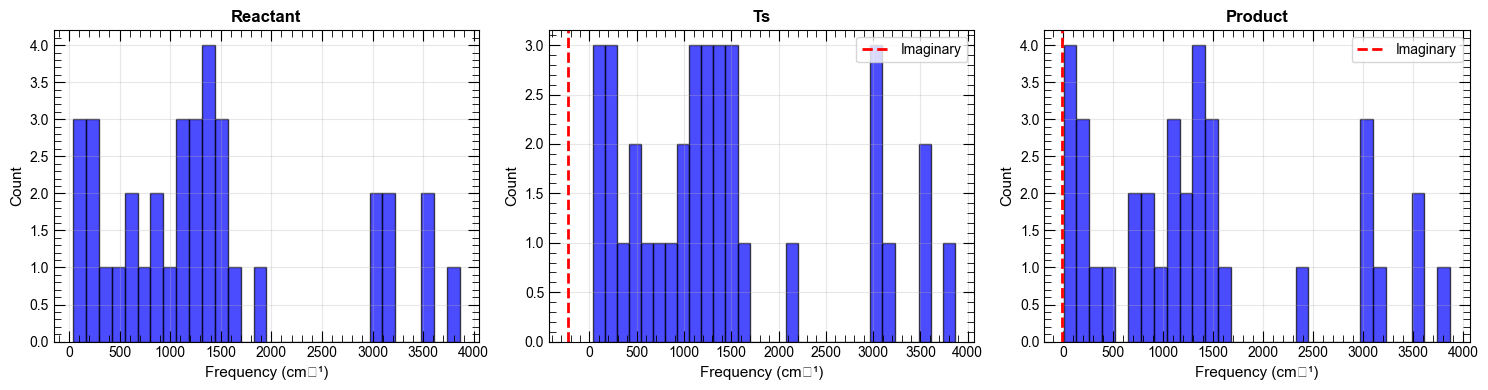

In [ ]:
# 振動数のヒストグラム
if len(data) > 0:
    fig, axes = plt.subplots(1, len(data), figsize=(5 * len(data), 4))
    if len(data) == 1:
        axes = [axes]

    for ax, (name, parsed_data) in zip(axes, data.items()):
        if "frequencies" in parsed_data:
            freqs = parsed_data["frequencies"]
            real_freqs = freqs[freqs > 0]
            imaginary_freqs = freqs[freqs < 0]

            # ヒストグラム
            if len(real_freqs) > 0:
                ax.hist(real_freqs, bins=30, alpha=0.7, color="blue", edgecolor="black")
            if len(imaginary_freqs) > 0:
                ax.axvline(
                    imaginary_freqs[0],
                    color="red",
                    linestyle="--",
                    linewidth=2,
                    label="Imaginary",
                )

            ax.set_xlabel("Frequency (cm⁻¹)", fontsize=11)
            ax.set_ylabel("Count", fontsize=11)
            ax.set_title(f"{name.capitalize()}", fontsize=12, fontweight="bold")
            ax.grid(True, alpha=0.3)
            if len(imaginary_freqs) > 0:
                ax.legend()

    plt.tight_layout()
    output_path = base_dir / "analysis" / "vibrational_frequencies.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"振動数分布を保存: {output_path}")
    plt.show()
else:
    print("データが読み込まれていません")

## 7. 最適化の収束履歴

In [14]:
# 最適化エネルギーの履歴（利用可能な場合のみ）
print("最適化履歴の抽出は直接ログから実装が必要です")
print("現在は最終エネルギーのみを表示しています")

最適化履歴の抽出は直接ログから実装が必要です
現在は最終エネルギーのみを表示しています


## 8. 結果のサマリー

In [ ]:
print("=" * 60)
print("反応解析サマリー")
print("=" * 60)

# エネルギー
if "reactant" in energies and "product" in energies:
    delta_E = (energies["product"] - energies["reactant"]) * 627.509474
    print(f"\n反応エネルギー (ΔE): {delta_E:+.2f} kcal/mol")
    if delta_E < 0:
        print("  → 発熱反応")
    else:
        print("  → 吸熱反応")

if "reactant" in energies and "ts" in energies:
    barrier = (energies["ts"] - energies["reactant"]) * 627.509474
    print(f"\n活性化エネルギー (Ea): {barrier:+.2f} kcal/mol")

# 虚振動の確認
print("\n構造の妥当性チェック:")
for name, parsed_data in data.items():
    if "frequencies" in parsed_data:
        freqs = parsed_data["frequencies"]
        n_imag = len(freqs[freqs < 0])

        if name == "ts":
            if n_imag == 1:
                print(f"  ✓ {name}: 虚振動1個（正しいTS）")
            else:
                print(f"  ⚠️  {name}: 虚振動{n_imag}個（要確認）")
        else:
            if n_imag == 0:
                print(f"  ✓ {name}: 虚振動なし（真の極小）")
            else:
                print(f"  ⚠️  {name}: 虚振動{n_imag}個（要再最適化）")

print("\n" + "=" * 60)

反応解析サマリー

反応エネルギー (ΔE): -0.69 kcal/mol
  → 発熱反応

活性化エネルギー (Ea): +2.63 kcal/mol

構造の妥当性チェック:
  ✓ reactant: 虚振動なし（真の極小）
  ✓ ts: 虚振動1個（正しいTS）
  ⚠️  product: 虚振動1個（要再最適化）



## 9. データのエクスポート

In [ ]:
# 結果をテキストファイルに保存
output_file = base_dir / "analysis" / "analysis_summary.txt"

with open(output_file, "w") as f:
    f.write("MEA + H2O + CO2 反応解析サマリー\n")
    f.write("=" * 60 + "\n\n")

    f.write("エネルギー (Hartree):\n")
    for name, energy in energies.items():
        f.write(f"  {name:12s}: {energy:.8f} Eh\n")

    f.write("\n相対エネルギー (kcal/mol):\n")
    if "reactant" in energies:
        ref = energies["reactant"]
        for name, energy in energies.items():
            rel = (energy - ref) * 627.509474
            f.write(f"  {name:12s}: {rel:+8.2f} kcal/mol\n")

    f.write("\n振動解析:\n")
    for name, parsed_data in data.items():
        if "frequencies" in parsed_data:
            freqs = parsed_data["frequencies"]
            n_imag = len(freqs[freqs < 0])
            f.write(f"  {name}: {n_imag} 個の虚振動\n")
            if n_imag > 0:
                for freq in freqs[freqs < 0]:
                    f.write(f"    {freq:.2f} cm⁻¹\n")

print(f"解析結果を保存: {output_file}")

解析結果を保存: /home/yamamoto/Work/chemistry/orca-work/MEA_water/analysis/analysis_summary.txt
